# Lecture 8: Confidence Intervals

---

## Outline

* [Percentiles](#Percentiles)
* [Estimation](#Estimation)
* [The Bootstrap](#The-Bootstrap)
* [Confidence Intervals](#Confidence-Intervals)

## Set Up the Notebook

In [1]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import scipy
import plotly.express as px
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

---

## Percentiles

---

### Computing Percentiles

The $p$-th percentile is the first value on the sorted list that is at least as large as $p$% of the elements. 

* The 80th percentile of `[1, 7, 3, 9, 5]` is the 4th ordered (`[1, 3, 5, 7, 9]`) element, 7:
* The 4th element is used because 80% of 5 is $(80/100) \cdot 5 = 4$
* For a percentile that does not exactly correspond to an element, take the next greater element instead
* For example the 65th percentile is also the 4th element, since $(65/100)\cdot 5 = 3.25$

---

### The percentile Function

* Function in the `datascience` module: `percentile(p, values)`
    * `p` is between 0 and 100
    * `values` is an array, list, etc.
    * Returns the `p`-th percentile of the array
* `percentile(80, s)` returns `7`

---

###  Percentiles

In [3]:
percentile?

Signature: percentile(p, arr=None)
Docstring:
Returns the pth percentile of the input array (the value that is at
least as great as p% of the values in the array).

If arr is not provided, percentile returns itself curried with p

>>> percentile(74.9, [1, 3, 5, 9])
5
>>> percentile(75, [1, 3, 5, 9])
5
>>> percentile(75.1, [1, 3, 5, 9])
9
>>> f = percentile(75)
>>> f([1, 3, 5, 9])
5
File:      /srv/conda/envs/notebook/lib/python3.11/site-packages/datascience/util.py
Type:      function

Compute the 55th percentile of the following array.

In [4]:
x = make_array(43, 20, 51, 7, 28, 34)

In [5]:
percentile(55, x)

34

In [2]:
nba = Table.read_table('nba2013.csv')
nba

Name,Position,Height,Weight,Age in 2013
DeQuan Jones,Guard,80,221,23
Darius Miller,Guard,80,235,23
Trevor Ariza,Guard,80,210,28
James Jones,Guard,80,215,32
Wesley Johnson,Guard,79,215,26
Klay Thompson,Guard,79,205,23
Thabo Sefolosha,Guard,79,215,29
Chase Budinger,Guard,79,218,25
Kevin Martin,Guard,79,185,30
Evan Fournier,Guard,79,206,20


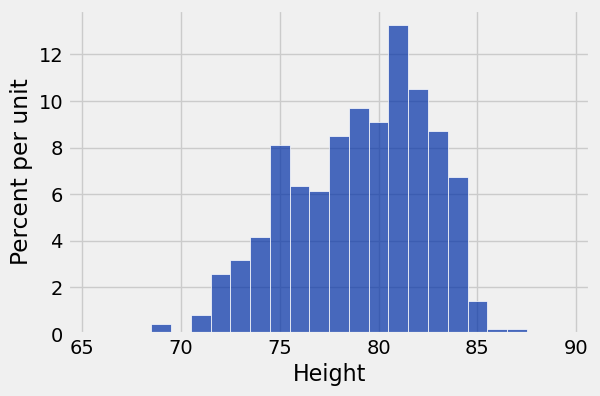

In [10]:
nba.hist('Height', bins = np.arange(65.5,90.5), ec='w')

In [3]:
heights = nba.column('Height')
heights

array([80, 80, 80, 80, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79,
       79, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,
       78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 77, 77, 77, 77, 77, 77, 77,
       77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77, 77,
       77, 77, 77, 77, 77, 76, 76, 76, 76, 76, 76, 76, 76, 76, 76, 76, 76,
       76, 76, 76, 76, 76, 76, 76, 76, 76, 76, 76, 76, 76, 76, 76, 76, 76,
       76, 76, 76, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75,
       75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75,
       75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 74, 74, 74, 74, 74, 74, 74,
       74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 74, 73, 73, 73,
       73, 73, 73, 73, 73, 73, 73, 73, 73, 73, 73, 73, 73, 72, 72, 72, 72,
       72, 72, 72, 72, 72, 72, 72, 72, 72, 71, 71, 71, 71, 69, 69, 84, 84,
       84, 84, 84, 83, 83, 83, 83, 83, 83, 83, 83, 83, 83, 83, 83, 83, 83,
       83, 82, 82, 82, 82

In [4]:
percentile(50,heights ), np.average(heights) 

(80, 79.065346534653472)

---

Show the idea behind the `percentile` function:
* Sort the array
* Calculate the value of the index corresponding to the percentile. Round up the value.

In [13]:
x = np.sort(x)
x

array([ 7, 20, 28, 34, 43, 51])

In [14]:
# item corresponding to the 55th percentile
np.ceil(55 / 100 * len(x))

4.0

In [15]:
# index of the item
index = int(np.ceil(55 / 100 * len(x))) - 1
index

3

In [16]:
x.item(index)

34

---

## Estimation

---

### Inference: Estimation

## Center and Spread
### Center (The Average/Mean)
The `average/mean` is a measure of center.

`Data`: 2, 3, 3, 9 

`Average` = (2+3+3+9)/4 = 4.25

* The average need not be a value in the data
* Need not be a whole number; must not rounnd it!
* It's somewhere in the middle but it doesn't have to be halfway in between
* Same units as the data

### Median vs. Mean
`Median`  : 50th percentile of the data

`Mean(Average)`: balance point of the histogram

If the distribution is symmetric about a value, then that value is both the average and the median

If the histogram is skewed (Non-symmetric), then the mean is pulled away from the median in the direction of the skew (tail)
* Physics analogy: center of gravity

How do we calculate the value of an unknown parameter?
* If you have a census (that is, the whole population): Just calculate the parameter and you're done
* If you don't have a census:
    * Take a random sample from the population
    * Use a statistic as an estimate of the parameter

---

### Demo: Sample Median Estimation

In [23]:
values = make_array(2, 3, 3, 9)
values

array([2, 3, 3, 9])

In [24]:
sum(values)/len(values)

4.25

In [25]:
np.average(values)

4.25

In [26]:
np.mean(values)

4.25

In [27]:
values_table = Table().with_columns('value', values)
values_table 

value
2
3
3
9


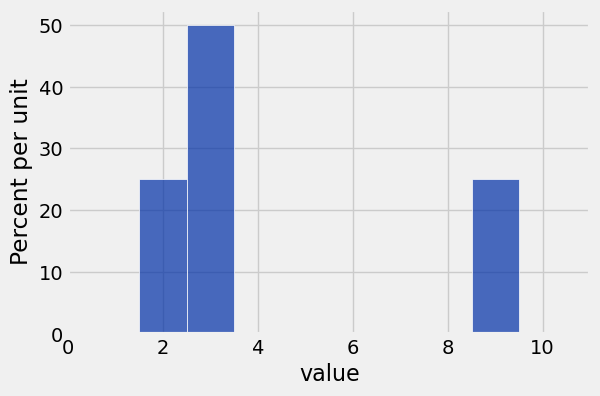

In [28]:
bins_for_display = np.arange(0.5, 10.6, 1)
values_table.hist('value', bins = bins_for_display, ec= 'w')

In [29]:
np.ones(10)

array([ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.])

In [30]:
twos = 2 * np.ones(10)
twos

array([ 2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.])

In [31]:
threes = 3 * np.ones(20)
threes

array([ 3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,
        3.,  3.,  3.,  3.,  3.,  3.,  3.])

In [32]:
nines = 9 * np.ones(10)
nines

array([ 9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.])

In [33]:
new_vals = np.append(np.append(twos, threes), nines)
new_vals

array([ 2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  3.,  3.,  3.,
        3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,
        3.,  3.,  3.,  3.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.])

In [34]:
## Make array of 10 2s, 20 3s, and 10 9s

new_vals = make_array(2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
                      3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
                      9, 9, 9, 9, 9, 9, 9, 9, 9, 9)

In [20]:
len(new_vals)

40

In [21]:
values_table = Table().with_columns('value', new_vals)
values_table

value
2
2
2
2
2
2
2
2
2
2


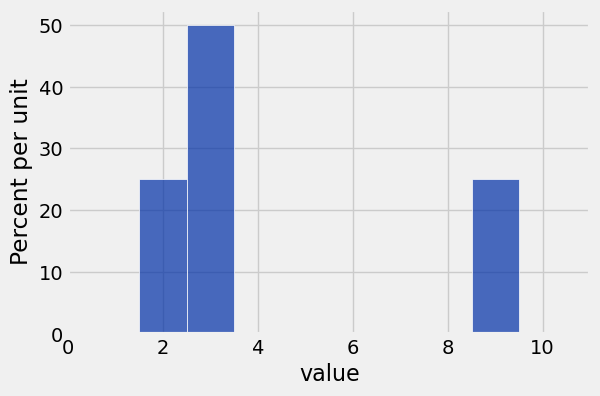

In [35]:
bins = bins_for_display

values_table.hist('value', bins = bins_for_display, ec= 'w')

In [36]:
np.average(new_vals)

4.25

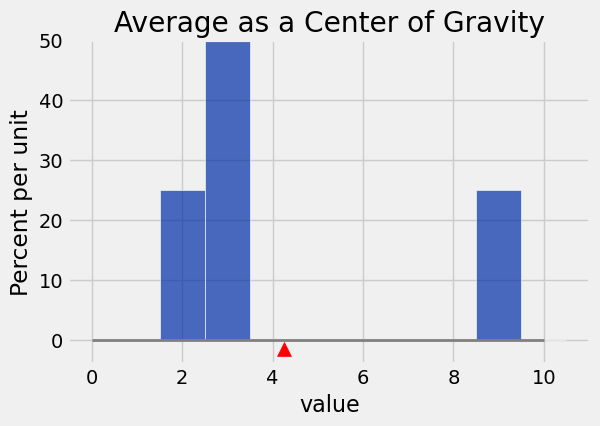

In [38]:
Table().with_column('value', new_vals).hist(bins = bins_for_display)
plt.ylim(-0.04, 0.5)
plt.plot([0, 10], [0, 0], color='grey', lw=2)
plt.scatter(4.25, -0.015, marker='^', color='red', s=100)
plt.title('Average as a Center of Gravity');

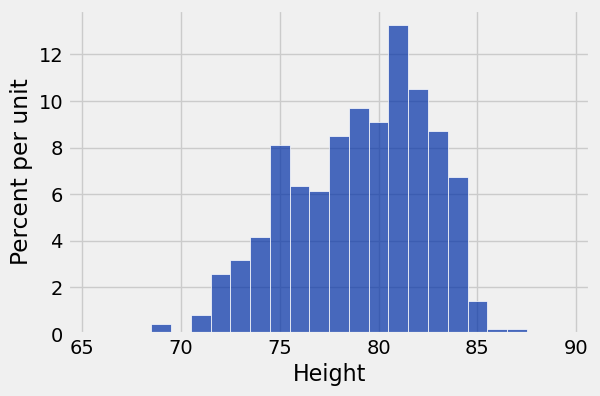

In [39]:
nba.hist('Height', bins = np.arange(65.5,90.5), ec='w')

In [41]:
births = Table.read_table('baby.csv')
births

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False
138,244,33,62,178,False
132,245,23,65,140,False
120,289,25,62,125,False
143,299,30,66,136,True
140,351,27,68,120,False


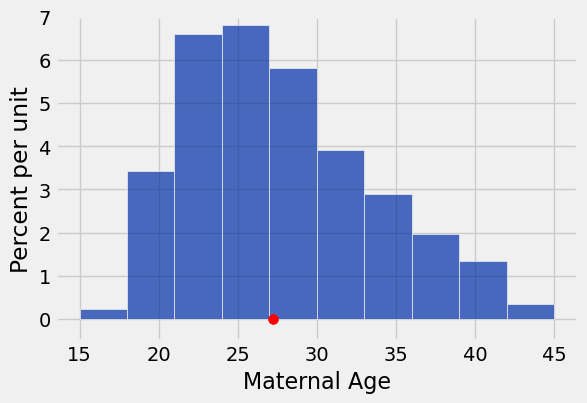

In [43]:
births.hist("Maternal Age")

plt.scatter(np.mean(births.column("Maternal Age")), 0, color='red', zorder=2, s=50);
plt.ylim(-0.005, 0.07);

(-0.005, 0.07)

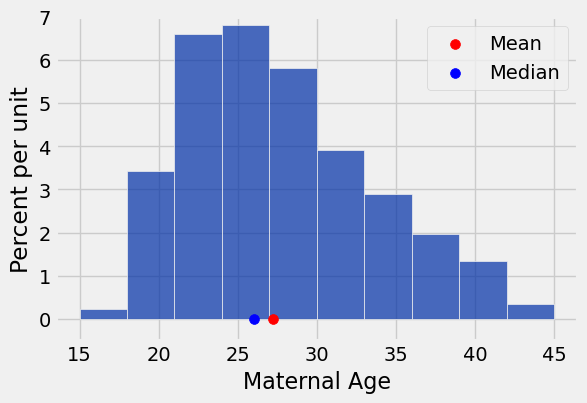

In [44]:
births.hist("Maternal Age")
plt.scatter(np.mean(births.column("Maternal Age")), 0, color='red', zorder=2, s=50, label="Mean")
plt.scatter(np.median(births.column("Maternal Age")), 0, color='blue', zorder=2, s=50, label="Median")
plt.legend()
plt.ylim(-0.005, 0.07)

* Since the distribution above is right skewed (which means it has a long right tail), we know that the mean of the distribution is larger than the median, which is the “halfway” point of the data. 

* Conversely, if the distribution had been left skewed, we know the mean would be smaller than the median.

---

### Variability of the Estimate

* One sample $\implies$ One estimate
* But the random sample could have come out differently
* And so the estimate could have been different
* **Big question**: How different would it be if we did it again?


### Quantifying Uncertainty

* The estimate is usually not exactly right: `Estimate = Parameter + Error`
* How accurate is the estimate, usually?
* When we have a census, we can do this by simulation


---

### Where to Get Another Sample?

* We want to understand the variability of our estimate
* Given the population, we could simulate... but we only have the sample!
* To get many values of the estimate, we needed many random samples
* We can't go back and sample again from the population:
    * No time, no money
* Stuck?


---

## The Bootstrap

---

### The Bootstrap

* A technique for simulating repeated random sampling
* All that we have is the original sample... which is large and random
* Therefore, it probably resembles the population
* So we sample at random from the original sample!

---

### The Problem

* All we have is the random sample
* We know it could have come out differently
* We need to know how different, to quantify the variability in estimates based on the sample
* So we need to create another sample ... or two ... or more


<img src="./the_problem.png" width=55%>

---

### Why the Bootstrap Works

All of the resamples look pretty **similar**, most likely.

<img src="./why_the_bootstrap_works.png" width=90%>

---

### Why We Need the Bootstrap

<img src="./why_we_need_the_bootstrap.png" width=90%>

---

### The Bootstrap Principle

Resampling from the original random sample $\approx$ Sampling from the population ... with high probability
* Useful method for estimating many parameters if the original random sample is large enough
* But doesn't work well for estimating some parameters




---

### Key to Resampling

* From the original sample,
    * draw at random
    * with replacement
    * as many values as the original sample contained
* The size of the new sample has to be the same as the original one, so that the two estimates are comparable


---

### The Bootstrap Process

---

#### One Random Sample

True but unknown distribution (population) → Random sample (the original sample)



---

#### Bootstrap

Empirical distribution of original sample (“population”) → Bootstrap sample 1
* → Estimate 1
* → Bootstrap sample 2
* → Estimate 2
* ...
* → Bootstrap sample 1000
* → Estimate 1000

---

---

## Confidence Intervals

---

### 95% Confidence Interval

* Interval of estimates of a parameter
* Based on random sampling
* 95% is called the confidence level
    * Could be any percent between 0 and 100
    * Higher level means wider intervals
* The confidence is in the process that gives the interval: It generates a "good" interval about 95% of the time.

---

# Interpreting Confidence

## Outline

* [Bootstrap Confidence Intervals](#Bootstrap-Confidence-Intervals)
* [Visualizing Confidence](#Visualizing-Confidence)
* [Use Methods Appropriately](#Use-Methods-Appropriately)
* [Confidence Intervals For Testing](#Confidence-Intervals-For-Testing)

---

## Bootstrap Confidence Intervals

---

### Bootstrap the Distribution of a Statistic

Simulation method to estimate the sample distribution of your statistic.

<img src="./bootstrap_from_pop.png" alt="Creating bootstrap resamples from a random sample from a population." width=60%>

<img src="./distribution_from_resamples.png" alt="Creating a sampling distribution and confidence interval from the resampled statistics." width=60%>

---

### A Bootstrap Confidence Interval

Construct a 95% confidence interval by taking the 2.5% and (100 - 2.5)% percentiles:

<img src="./95_ci.png" alt="A 95% C.I. formed from the distribution of resampled statistics." width=40%>

---

### The Bootstrap in Words

* From the original sample,
    * draw at random
    * **with replacement**
        * Otherwise you would always get the same sample
    * **Use the same sample size** as the original sample
        * The size of the new sample has to be the same as the original one, so that estimates are comparable 
* For each sample, **compute the statistic**
* Compute **empirical distribution of the statistics**


---

## Visualizing Confidence

---

### 95% Confidence Interval

* Interval of estimates of a parameter
* Based on random sampling
* 95% is called the confidence level
    * Could be any percent between 0 and 100
    * Higher level means wider intervals
* A "good" interval is one that contains the parameter
* The confidence is in the process that creates the interval:
    * It generates a "good" interval about 95% of the time.


---

### The Meaning of 95% Confidence

> The confidence is in the process that gives the interval: It generates a "good" interval about 95% of the time.

<img src="./visualizing_confidence.png" width=30%>

* Each yellow line in the visual represents a confidence interval from a fresh sample from the population.
* The red line marks the parameter being estimated by the intervals.
* Approximately 95% of the yellow lines intersect the red line.

---

## Use Methods Appropriately

---

### When Not to Use Our Bootstrap Method

* If you're trying to estimate any parameter that's greatly affected by rare elements of the population
very high or very low percentiles, or min and max
* If the probability distribution of your statistic is not roughly bell-shaped (the shape of the empirical distribution will be a clue)
* If the original sample is very small

---

### Create a Confidence Interval for Unknown Population Mean

* Load the `baby.csv` data from the Kaiser-supported study on the relationship between smoking during pregnancy and low-weight births.
* Visualize the distribution of maternal ages.
* Compute the mean age of mothers in the sample.

In [45]:
births = Table.read_table('baby.csv')
births

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False
138,244,33,62,178,False
132,245,23,65,140,False
120,289,25,62,125,False
143,299,30,66,136,True
140,351,27,68,120,False


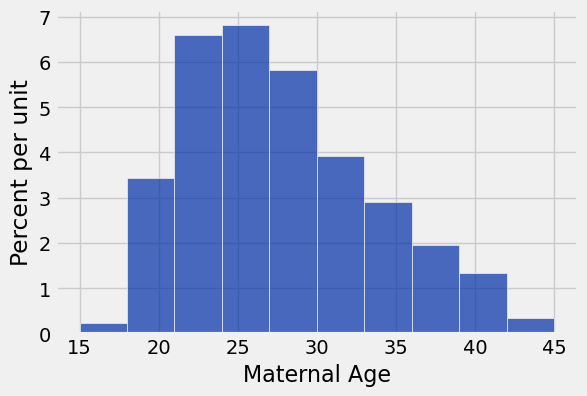

In [54]:
births.hist('Maternal Age')

In [53]:
np.mean(births.column('Maternal Age'))

27.228279386712096

In [52]:
def one_bootstrap_mean():
    resample = births.sample()
    return np.average(resample.column('Maternal Age'))

In [55]:
# Generate means from 5000 bootstrap samples
num_repetitions = 5000
bstrap_means = make_array()
for i in np.arange(num_repetitions):
    bstrap_means = np.append(bstrap_means, one_bootstrap_mean())

In [56]:
# Get the endpoints of the 95% confidence interval
left = percentile(2.5, bstrap_means)
right = percentile(97.5, bstrap_means)

make_array(left, right)

array([ 26.89011925,  27.55792164])

In [ ]:
resampled_means = Table().with_columns(
    'Bootstrap Sample Mean', bstrap_means
)
resampled_means.hist(bins=15)
plots.plot([left, right], [0, 0], color='yellow', lw=8);

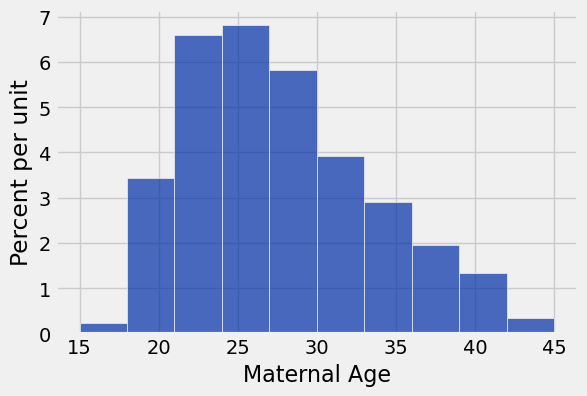

In [57]:
births.select('Maternal Age').hist()

---

### An Incorrect Use

#### Confidence Interval
By our calculation, an approximate 95% confidence interval for the average age of the mothers in the population is (26.9, 27.6) years.

#### Incorrect Statement
About 95% of the mothers in the population were between 26.9 years and 27.6 years old.

#### Reasoning
We're estimating that their average age is in this interval.

---

### An Incorrect Interpretation

#### Confidence Interval
An approximate 95% confidence interval for the average age of the mothers in the population is (26.9, 27.6) years.

#### Incorrect Statement
There is a 0.95 probability that the average age of mothers in the population is in the range 26.9 to 27.6 years.

#### Reasoning
The parameter is fixed, and the interval (26.9, 27.6) is fixed. The parameter is either in that interval or not. Once you've picked an interval, there's no probability involved.

---

### A Correct Interpretation

#### Confidence Interval
An approximate 95% confidence interval for the average age of the mothers in the population is (26.9, 27.6) years.

#### Correct Statement
If we generated confidence intervals in the same way many times, then approximately 95% of the intervals would contain the true average age of mothers in the population.

---

### Another Correct Interpretation

#### Confidence Interval
An approximate 95% confidence interval for the average age of the mothers in the population is (26.9, 27.6) years.

#### Correct Statement
There is a 95% chance the 95% confidence interval calculated from a given **future** sample will contain the average age of the mothers in the population.

---

### 95% Confidence

* Interval of estimates of a parameter
* Based on random sampling
* The process results in a random interval
* A "good" interval is one that contains the parameter
* The confidence is in the process that creates the interval: It generates a "good" interval (approximately) 95% of the time.


---

## Confidence Intervals For Testing

---

### Using a CI for Testing

* Null hypothesis: $\text{Population mean} = x$
* Alternative hypothesis: $\text{Population mean} \neq x$
* Cutoff for p-value: p%
* Method:
    * Construct a (100-p)% confidence interval for the population mean
    * Make a decision:
        * If x is not in the interval, reject the null
        * If x is in the interval, can't reject the null


---

### Using the Confidence Interval for Testing Hypotheses

* **Null Hypothesis:** The mean age of mothers in the population is 25 years; the random sample average is different due to chance.
* **Alternative Hypothesis:** The mean age of the mothers in the population is not 25 years.
* **Cutoff**: Suppose you use the 5% cutoff for the p-value.

Since 25 is not in the constructed 95% confidence interval estimate for the mean age (26.9, 27.6), then reject the null hypothesis.

---

# Center and Spread

---

## Outline

* [Center and Spread](#Center-and-Spread)
* [Average](#Average)
* [Standard Deviation](#Standard-Deviation)
* [Chebyshev's Inequality](#Chebyshev's-Inequality)
* [Standard Units](#Standard-Units)

---

## Center and Spread

---

### Topic Motivation

* How can we quantify natural concepts like "center" and "variability"?
* Why do many of the empirical distributions that we generate come out bell shaped?
* How is sample size related to the accuracy of an estimate?

---

## Average

---

### The Average (or Mean)

* Example
    * Data: 2, 3, 3, 9    
    * The average of 4.25 is calculated as $\frac{2+3+3+9}{4}$
* Need not be a value in the collection
* Need not be an integer even if the data are integers
* Somewhere between min and max, but not necessarily halfway in between
* Same units as the data
* Smoothing operator: collect all the contributions in one big pot, then split evenly

---

### Average (Mean)

Explore various ways to calculate and interpret the average.

In [ ]:
values = make_array(2, 3, 3, 9)

In [ ]:
np.average(values)

In [ ]:
np.mean(values)

In [ ]:
sum(values) / len(values)

In [ ]:
(2 + 3 + 3 + 9) / 4

---

Notice how the average reflects a physical balancing point for the data visualized through a histogram.

In [59]:
values_table = Table().with_columns('value', values)
values_table

value
2
3
3
9


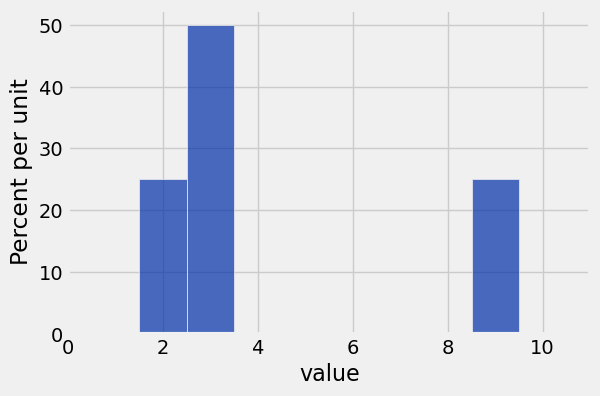

In [60]:
bins_for_display = np.arange(0.5, 10.6, 1)
values_table.hist(0, bins = bins_for_display)

In [61]:
new_vals = make_array(2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
                      3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
                      9, 9, 9, 9, 9, 9, 9, 9, 9, 9)

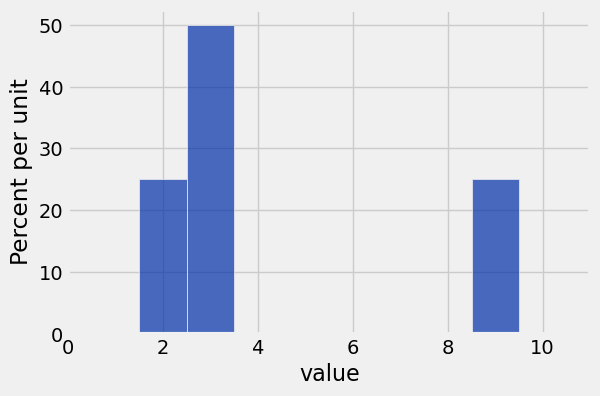

In [62]:
Table().with_column('value', new_vals).hist(bins = bins_for_display)

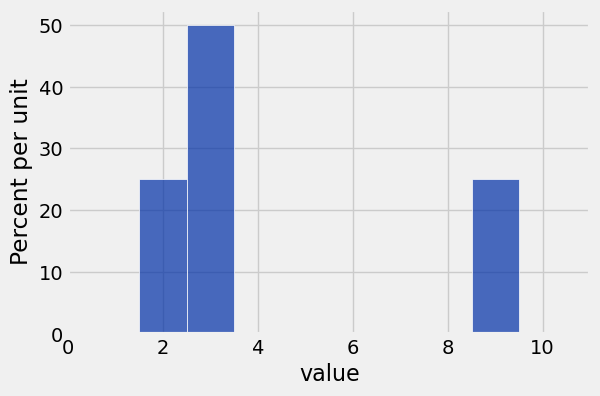

In [63]:
bins_for_display = np.arange(0.5, 10.6, 1)
values_table.hist('value', bins = bins_for_display, ec= 'w')

In [64]:
births = Table.read_table('baby.csv')
births

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False
138,244,33,62,178,False
132,245,23,65,140,False
120,289,25,62,125,False
143,299,30,66,136,True
140,351,27,68,120,False


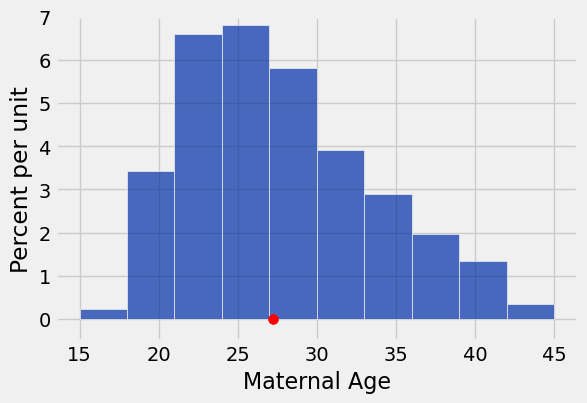

In [66]:
births.hist("Maternal Age")

plt.scatter(np.mean(births.column("Maternal Age")), 0, color='red', zorder=2, s=50);
plt.ylim(-0.005, 0.07);


(-0.005, 0.07)

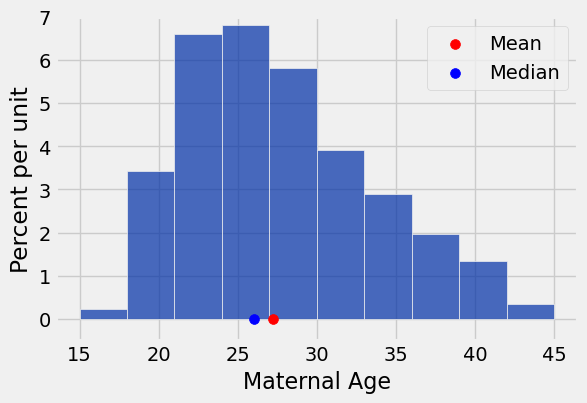

In [67]:
births.hist("Maternal Age")
plt.scatter(np.mean(births.column("Maternal Age")), 0, color='red', zorder=2, s=50, label="Mean")
plt.scatter(np.median(births.column("Maternal Age")), 0, color='blue', zorder=2, s=50, label="Median")
plt.legend()
plt.ylim(-0.005, 0.07)

* Since the distribution above is right skewed (which means it has a long right tail), we know that the mean of the distribution is larger than the median, which is the “halfway” point of the data. 

* Conversely, if the distribution had been left skewed, we know the mean would be smaller tha

---

### Reflection

<img src="./histograms.png" width = 80%>

* Are the medians of these two distributions the same or different? 
* Are the means the same or different? 
* If you say "different," then say which one is bigger.

---

### Comparing Mean and Median 

* Mean: Balance point of the histogram
* Median: Half-way point of data; half the area of histogram is on either side of median
* If the distribution is symmetric about a value, then that value is both the average and the median.
* If the histogram is skewed, then the mean is pulled away from the median in the direction of the tail.

---

### Reflection

<img src="./nba.png" width = 50%>

Is the mean or median larger for the distribution of NBA player heights?

---

## Standard Deviation

### How Far from the Average?

The SD of an array is defined as the root mean square of the deviations where the deviations are the difference between the original elements and their average.

* `Standard deviation (SD)` measures roughly how far the data are from their average
* SD = Root Mean Square of Deviations from Average
              
         <-- 5 <-- 4 <-- 3 <-- 2 <--- 1
   
   Also known as the RMS (Root Mean Square)
   
* SD has the same units as the data

### How Big are Most of the Values?

* No matter what the shape of the distribution, the bulk of the data are in the range

### "average +- a few SDs"

---

### Defining Variability

* Plan A: “biggest value - smallest value”
    * Doesn’t tell us much about the shape of the distribution
* Plan B:
    * Measure variability around the mean
    * Need to figure out a way to quantify this


---

### Standard Deviation

Develop the standard deviation formula.

In [ ]:
values = make_array(2, 3, 3, 9)

In [ ]:
sd_values = Table().with_columns('values',values)
sd_values 

In [ ]:
# Step 1. The average.

mean = np.mean(values)
mean

In [ ]:
deviations = values - mean
deviations

In [ ]:
# Step 2. The deviations from average.

calculation_steps = Table().with_columns(
        'Value', values,
        'Deviation from Average', deviations
        )
calculation_steps

In [ ]:
sum(deviations)

In [ ]:
np.mean(deviations)

In [ ]:
# Step 3. The squared deviations from average

squared_deviations = deviations ** 2
calculation_steps = calculation_steps.with_column(
   'Squared Deviations from Average', squared_deviations
    )
calculation_steps

In [ ]:
# Step 4. Variance = the mean squared deviation from average

variance = np.mean(squared_deviations)
variance

In [ ]:
# Step 5.
# Standard Deviation: root mean squared deviation from average
# Steps of calculation:   5    4      3       2             1

sd = variance ** 0.5
sd

In [ ]:
np.std(values)

---

### How Far from the Average?

* Standard deviation (SD) measures roughly how far the data are from their average
* SD = root mean square of deviations from average
* SD has the same units as the data

---

### Why Use the SD?

There are two main reasons for us.

1. No matter what the shape of the distribution, the bulk of the data are in the range "average ± a few SDs" (Chebyshev's Inequality)
2. ... coming up in a future lecture.

---

`Chebyshev's Inequality`: 

no matter the shape of the distribution, the proportion of values in the range "mean +- z SDs" is at least 1 - 1/z^2

## Chebyshev’s Bounds

Range	           Proportion	                             
 
average ± 2 SDs	at least 1 - 1/4 = 3/4 (75%)	               

average ± 3 SDs	at least 1 - 1/9 = 8/9 (88.88…%)	           

average ± 4 SDs	at least 1 - 1/16 = 15/16 (93.75%)           	

average ± 5 SDs	at least 1 - 1/25 = 24/25 (96%) 	           

## Standard Units

In the calculations above, the quantity measures standard units, the number of standard deviations above average.

Some values of standard units are negative, corresponding to original values that are below average. Other values of standard units are positive. 

To convert a value to standard units, first find how far it is from average, and then compare that deviation with the standard deviation.

`Z-score`: 

z = (value - average) / SD

Mean + 2SD = 2 standard units

Mean + SD = 1 standard units

Mean = 0 standard units

Mean - SD = -1 standard units

Mean - 2SD = -2 standard units


---

### How Big are Most of the Values?

* No matter what the shape of the distribution, the bulk of the data are in the range "average ± a few SDs"
* Chebyshev’s Inequality
    * No matter what the shape of the distribution, the proportion of values in the range "average ± $z$ SDs" is at least $1 - 1/z^2$



---

### Chebyshev's Bounds


No matter what the distribution looks like, the proportion of data values follows:

<img src="./cheby_bounds.png" width=50%>

---

### Demo: Chebyshev's Bound

Demonstrate Chebyshev's bounds through a data set.

In [4]:
births = Table.read_table('baby.csv')
births.show(3)

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True


In [68]:
# [:-1] excludes the last column label
numerical_labels = births.labels[:-1]
numerical_labels

('Birth Weight',
 'Gestational Days',
 'Maternal Age',
 'Maternal Height',
 'Maternal Pregnancy Weight')

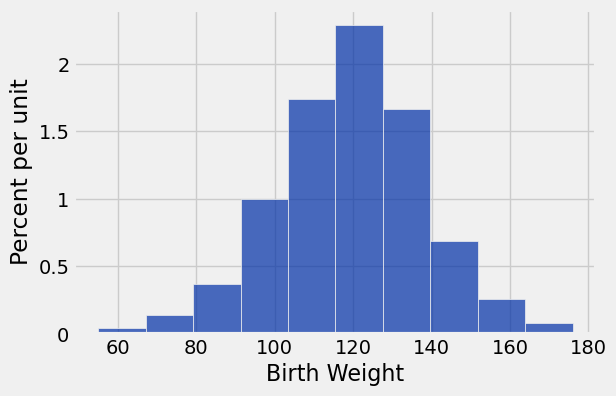

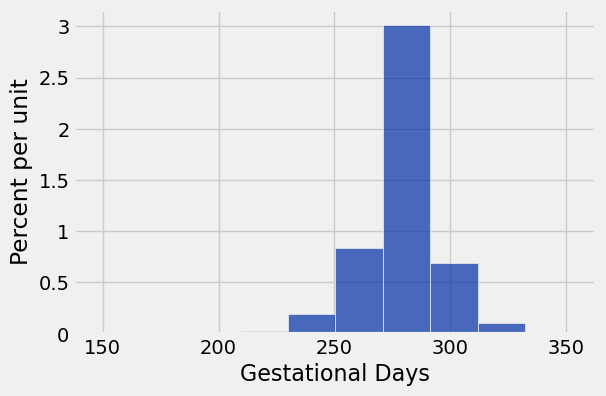

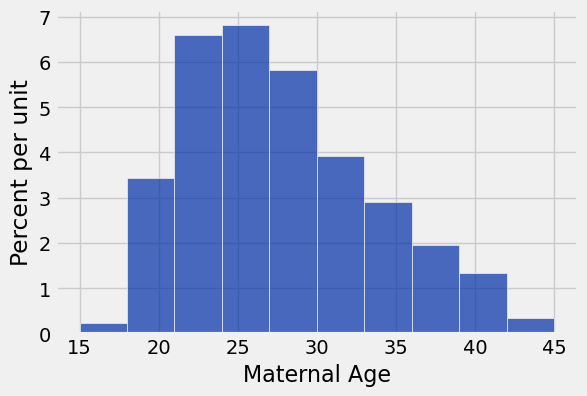

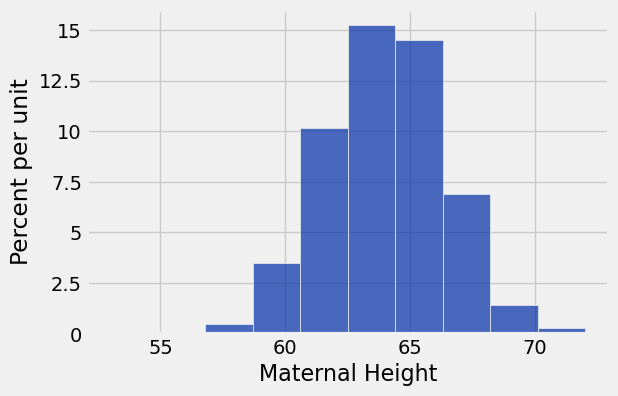

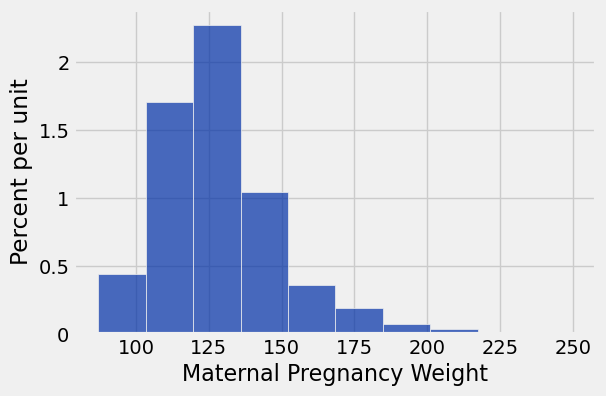

In [69]:
for column_label in numerical_labels: 
    births.hist(column_label)

In [ ]:
age_mean = np.mean(births.column("Maternal Age")) 
age_mean

In [70]:

age_sd = np.std(births.column("Maternal Age"))
age_sd


5.8153604041908968

(-0.005, 0.07)

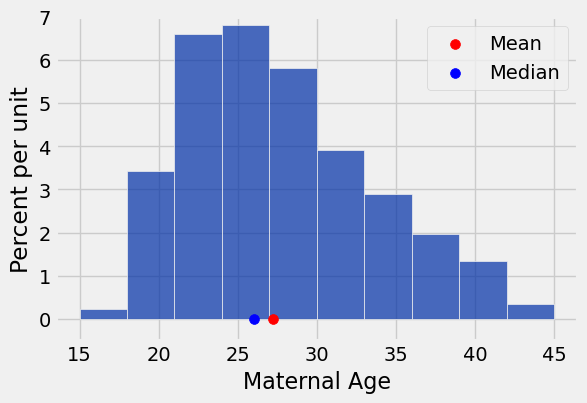

In [71]:
births.hist("Maternal Age")
plt.scatter(np.mean(births.column("Maternal Age")), 0, color='red', zorder=2, s=50, label="Mean")
plt.scatter(np.median(births.column("Maternal Age")), 0, color='blue', zorder=2, s=50, label="Median")
plt.legend()
plt.ylim(-0.005, 0.07)

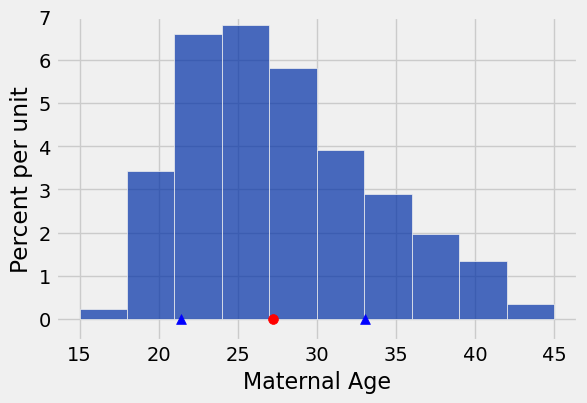

In [74]:
age_mean = np.mean(births.column("Maternal Age")) 
age_sd = np.std(births.column("Maternal Age"))
births.hist("Maternal Age")

plt.scatter(age_mean, 0, color='red', zorder=2, s=50);
plt.scatter(age_mean+age_sd, 0, marker='^', color='blue', zorder=2, s=50);
plt.scatter(age_mean-age_sd, 0, marker='^', color='blue', zorder=2, s=50);
plt.ylim(-0.005, 0.07);

In [75]:
births.labels

('Birth Weight',
 'Gestational Days',
 'Maternal Age',
 'Maternal Height',
 'Maternal Pregnancy Weight',
 'Maternal Smoker')

In [77]:
mpw = births.column('Maternal Pregnancy Weight')
mean = np.mean(mpw)
sd = np.std(mpw)
mean, sd

(128.4787052810903, 20.725449704280411)

In [78]:
within_3_SDs = births.where(
    'Maternal Pregnancy Weight', are.between(mean - 3*sd, mean + 3*sd))
within_3_SDs

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False
138,244,33,62,178,False
132,245,23,65,140,False
120,289,25,62,125,False
143,299,30,66,136,True
140,351,27,68,120,False


In [79]:
 births.num_rows

1174

In [80]:
within_3_SDs.num_rows

1158

In [81]:
# Proportion within 3 SDs of the mean

within_3_SDs.num_rows / births.num_rows

0.9863713798977853

In [82]:
# Chebyshev's bound: 
# This proportion should be at least

1 - 1/3**2

0.8888888888888888

In [83]:
# See if Chebyshev's bounds work for distributions with various shapes

for feature in births.labels:
    values = births.column(feature)
    mean = np.mean(values)
    sd = np.std(values)
    print()
    print(feature)
    for z in make_array(2, 3, 4, 5):
        chosen = births.where(feature, are.between(mean - z*sd, mean + z*sd))
        proportion = chosen.num_rows / births.num_rows
        percent = round(proportion * 100, 2)
        print('Average plus or minus', z, 'SDs:', percent, '%')


Birth Weight
Average plus or minus 2 SDs: 94.89 %
Average plus or minus 3 SDs: 99.57 %
Average plus or minus 4 SDs: 100.0 %
Average plus or minus 5 SDs: 100.0 %

Gestational Days
Average plus or minus 2 SDs: 93.78 %
Average plus or minus 3 SDs: 98.64 %
Average plus or minus 4 SDs: 99.57 %
Average plus or minus 5 SDs: 99.83 %

Maternal Age
Average plus or minus 2 SDs: 94.89 %
Average plus or minus 3 SDs: 99.91 %
Average plus or minus 4 SDs: 100.0 %
Average plus or minus 5 SDs: 100.0 %

Maternal Height
Average plus or minus 2 SDs: 97.19 %
Average plus or minus 3 SDs: 99.66 %
Average plus or minus 4 SDs: 99.91 %
Average plus or minus 5 SDs: 100.0 %

Maternal Pregnancy Weight
Average plus or minus 2 SDs: 95.06 %
Average plus or minus 3 SDs: 98.64 %
Average plus or minus 4 SDs: 99.49 %
Average plus or minus 5 SDs: 99.91 %

Maternal Smoker
Average plus or minus 2 SDs: 100.0 %
Average plus or minus 3 SDs: 100.0 %
Average plus or minus 4 SDs: 100.0 %
Average plus or minus 5 SDs: 100.0 %


---

## Standard Units

---

### Standard Units

* How many SDs above average?
* `z = (value - average)/SD`
    * Negative z: value below average
    * Positive z: value above average
    * z = 0: value equal to average
* When values are in standard units: average = 0, SD = 1
* Gives us a way to compare/understand data no matter what the original units


---

### Standard Units

Create a function to convert a measurement to standard units and apply it to the previous data set.

### Standard Units

#### standard units = (original value - mean) / SD

<img src="Lecture 25_ Center and Spread.jpg" alt="drawing" width="500"/>


In [84]:
def standard_units(x):
    """Convert array x to standard units."""
    return (x - np.mean(x)) / np.std(x)

In [85]:
ages = births.column('Maternal Age')
ages

array([27, 33, 28, ..., 30, 21, 38])

In [86]:
ages_standard_units = standard_units(ages)
ages_standard_units

array([-0.03925456,  0.99249577,  0.13270383, ...,  0.47662061,
       -1.07100488,  1.85228771])

In [87]:
np.mean(ages_standard_units), np.std(ages_standard_units)

(-7.868020072300939e-17, 1.0)

In [88]:
both = Table().with_columns(
    'Age in Years', ages,
    'Age in Standard Units', ages_standard_units
)
both

Age in Years,Age in Standard Units
27,-0.0392546
33,0.992496
28,0.132704
23,-0.727088
25,-0.383171
33,0.992496
23,-0.727088
25,-0.383171
30,0.476621
27,-0.0392546


In [89]:
np.mean(ages), np.std(ages)

(27.228279386712096, 5.8153604041908968)

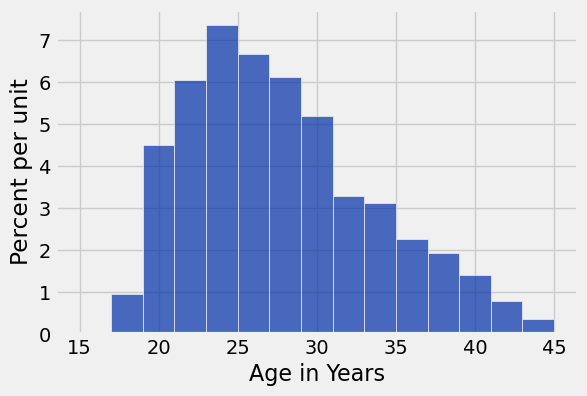

In [90]:
both.hist('Age in Years', bins = np.arange(15, 46, 2))

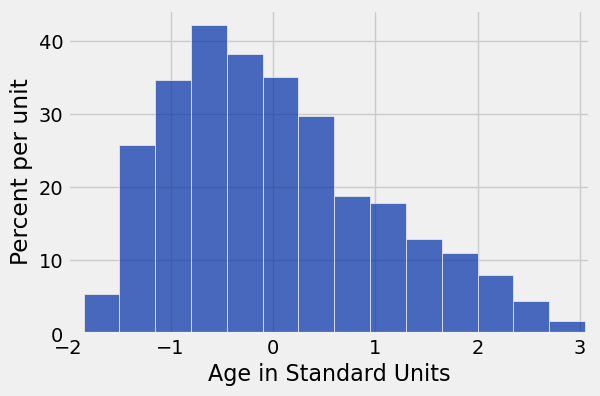

In [91]:
both.hist('Age in Standard Units', bins = np.arange(-2.2, 3.4, 0.35))
plt.xlim(-2, 3.1);

---

### The SD and the Histogram

* Usually, it's not easy to estimate the SD by looking at a histogram.
* But if the histogram has a bell shape, then you can.


---

### The SD and Bell-Shaped Curves

If a histogram is bell-shaped, then
* the average is at the center
* the SD is the distance between the average and the points of inflection on either side


---

### Demo: The SD and Bell Shaped Curves

Notice the way the distribution changes around $\pm 1$ of the mean.

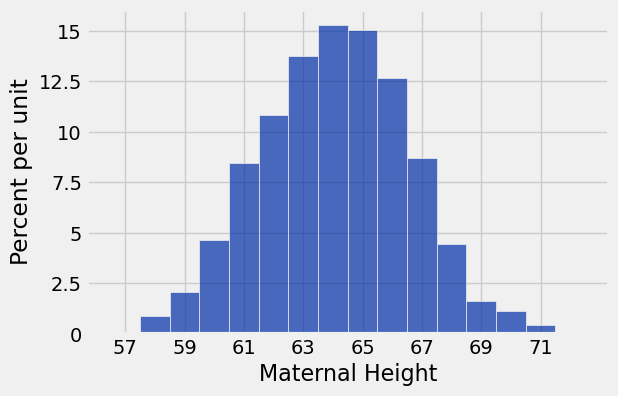

In [92]:
births.hist('Maternal Height', bins = np.arange(56.5, 72.6, 1))
plt.xticks(np.arange(57, 72, 2));

In [93]:
heights = births.column('Maternal Height')
np.mean(heights), np.std(heights)

(64.049403747870528, 2.5250254409674375)

---

### Point of Inflection

<img src="./inflection_points.png" width =50%>

The curvature of shape of the histogram changes at one standard deviation below the mean and one standard deviation above the mean.

---

### How Accurate is the Sample Mean?

In short, the smaller the SD, the more accurate the estimate of the sample mean as an estimate of the population mean

Why is this? The population SD is a constant, so variability of the sample mean decreases as the sample mean increases


In [96]:
united = Table.read_table('united.csv')
united_bins = np.arange(-20, 300, 10)
united

Date,Flight Number,Destination,Delay
6/1/15,73,HNL,257
6/1/15,217,EWR,28
6/1/15,237,STL,-3
6/1/15,250,SAN,0
6/1/15,267,PHL,64
6/1/15,273,SEA,-6
6/1/15,278,SEA,-8
6/1/15,292,EWR,12
6/1/15,300,HNL,20
6/1/15,317,IND,-10


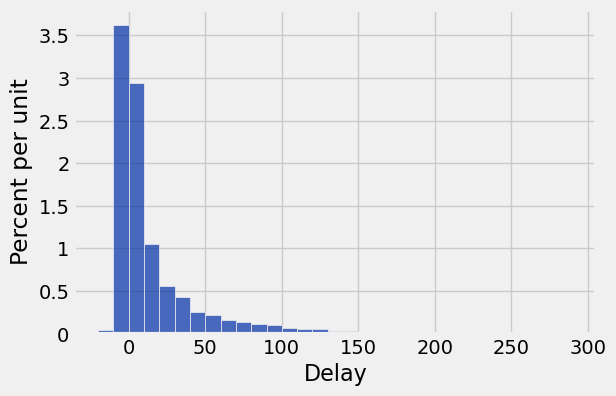

In [97]:
united.hist('Delay', bins=united_bins)

In [98]:
delays = united.column('Delay')
delay_mean = np.mean(delays)
delay_sd = np.std(delays)
delay_mean, delay_sd

(16.658155515370705, 39.480199851609314)

In [99]:
percentile(50, delays)

2

In [100]:
def one_sample_mean(sample_size):
    """ 
    Takes a sample from the population of flights 
    and computes its mean
    """
    sampled_flights = united.sample(sample_size)
    return np.mean(sampled_flights.column('Delay'))

In [101]:
one_sample_mean(100)

16.629999999999999

In [102]:
def ten_thousand_sample_means(sample_size):
    means = make_array()
    for i in np.arange(10000):
        mean = one_sample_mean(sample_size)
        means = np.append(means, mean)
    return means

In [103]:
sample_means_100 = ten_thousand_sample_means(100)

In [104]:
len(sample_means_100)

10000

Population Average: 16.6581555154


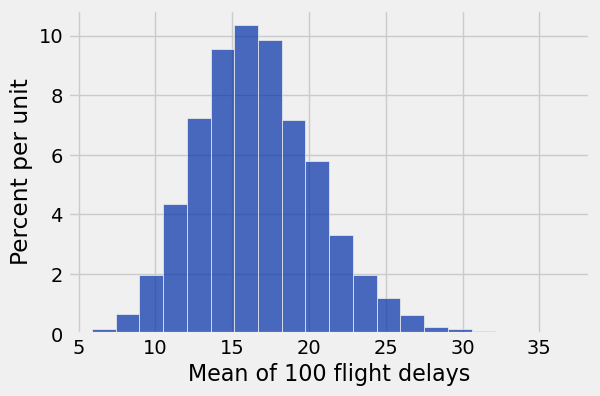

In [105]:
Table().with_column(
    'Mean of 100 flight delays', sample_means_100).hist(bins=20)

print('Population Average:', delay_mean)

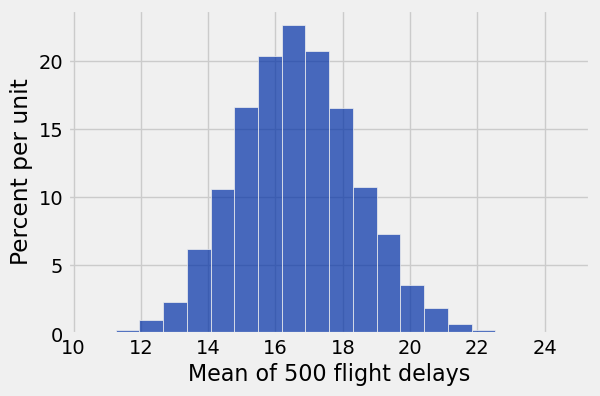

In [106]:
sample_means_500 = ten_thousand_sample_means(500)
Table().with_column('Mean of 500 flight delays', sample_means_500).hist(bins=20)

In [107]:
united.num_rows

13825

In [108]:
# How many possible sample means are there?
united.num_rows ** 500

2150651237835806708297273426035479600152121278263354854749683047597839202346303956865975903612584405994349534711882652620649409045089753205846914338186151722146796416499635421135774355389352146516377522482989859921756314016822454879839718509017413441036793639470544165429873191612403181851275088139159119236606639564907734824547568070149440790541578131581538956328166653842573781074850641418389859289016052764529408398849394115631760140215834053537549252693622747303417082402051090128545224165406043994214731387819432222245304887342115032714375928808238664559203473388548057161408363842593468086802922231062789420113327952927669326754048073891332452460186969008421458782980925297866458277880698230320124002827090750934443325060344228941664480780045153293064141992618861867795849484747832371630056525720355991564960700561323066478076000280361784770184309879590106730932984193637466525692994869405943710626544994339435060272015391996383016063838506876036868200103740893772004092794903259612698167954317

## CLT: Center

Population Average: 16.6581555154


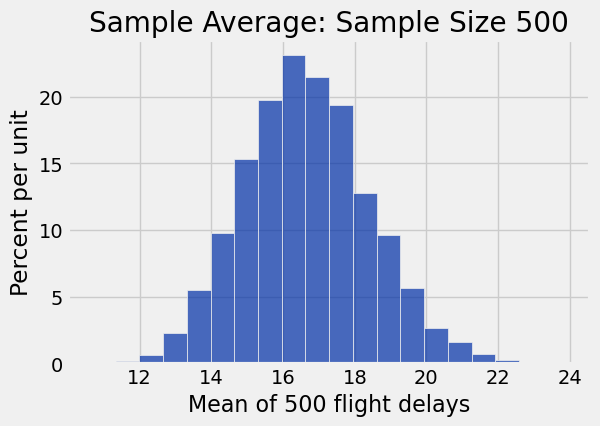

In [109]:
delay_mean = np.average(united.column('Delay'))
sample_means_500 = ten_thousand_sample_means(500)
Table().with_column('Mean of 500 flight delays', sample_means_500).hist(bins=20)
print('Population Average:', delay_mean)
plt.title('Sample Average: Sample Size 500');

# The Normal Distribution

---

## Outline

* [Standard Units Review](#Standard-Units-Review)
* [Normal Distributions](#Normal-Distributions)
* [Normal Proportions](#Normal-Proportions)

---

## Standard Units Review

* How many SDs above average?
* `z = (value - average)/SD`
    * Negative z: value below average
    * Positive z: value above average
    * z = 0: value equal to average
* When values are in standard units: average = 0, SD = 1
* Gives us a way to compare/understand data no matter what the original units


---

## Normal Distributions

---

### Bell-Shaped Curves

---

### Probability Density Curve

The height of the (probability density) curves are determined by the formula*

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{1}{2}\left(\frac{x - \mu}{\sigma}\right)^2}$$

and the shape is determined by the mean (`mu`, $\mu$) and standard deviation (`sigma`, $\sigma$) values.

_Note: You will not be working with this formula directly in this class, but we can use a python representation of it (`scipy.stats.norm.pdf`) to see how the mean and standard deviation impact the shape of the distribution._

In [110]:
def graph_norm(mu=0, sigma=1):
    x=np.arange(-10, 10, 0.01)
    display(px.line(x=x, 
                    y=scipy.stats.norm.pdf(x, loc=mu, scale=sigma), 
                    range_y=[0, 1]));

Adjust the values of `mu` and `sigma` using the slider to see how the shape of the distribution changes.

In [111]:
interact(graph_norm, mu=(-5, 5), sigma=(0.2**0.5, 5**0.5, 0.05));

interactive(children=(IntSlider(value=0, description='mu', max=5, min=-5), FloatSlider(value=1.0, description=…

---

## Normal Proportions

---

### How Big are Most of the Values?

* No matter what the shape of the distribution, the bulk of the data are in the range "average ± a few SDs" (Chebyshev's Inequality)
* **If a histogram is bell-shaped**, then almost all of the data are in the range "average ± 3 SDs"


---

### Bounds and Normal Approximations

<img src="./normal_bounds.png" width = 50%>

---

### A "Central" Area

<img src="./central_area.png" width = 50%>

---

## Attribution

This content is licensed under the <a href="https://creativecommons.org/licenses/by-nc-sa/4.0/">Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License (CC BY-NC-SA 4.0)</a> and derived from the <a href="https://www.data8.org/">Data 8: The Foundations of Data Science</a> offered by the University of California, Berkeley.

<img src="./by-nc-sa.png" width=100px>